# Seq2Seq: Generowanie Tekstu na Podstawie Polskiej Literatury
### Kurs: Języki Naturalne w SI &nbsp;|&nbsp; Keras / TensorFlow

---

## Co to jest model Seq2Seq?

**Sekwencja-do-sekwencji** (ang. *sequence-to-sequence*, seq2seq) to architektura sieci neuronowej
zaprojektowana do przekształcania jednej sekwencji w drugą. Pierwotnie opracowana do **tłumaczenia
maszynowego** (Sutskever et al., 2014), dziś stosowana jest w:
- generowaniu tekstu i streszczaniu,
- systemach dialogowych (chatboty),
- rozpoznawaniu i syntezie mowy,
- odpowiadaniu na pytania.

Model składa się z dwóch bloków LSTM:

| Blok | Rola |
|------|------|
| **Enkoder** (*encoder*) | Czyta sekwencję wejściową i kompresuje ją do **wektora kontekstu** `[h, c]` |
| **Dekoder** (*decoder*) | Przyjmuje wektor kontekstu i generuje sekwencję wyjściową **znak po znaku** |

```
╔══════════════════════════════════════════════════════════════════════╗
║                    TRENING  (Teacher Forcing)                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Wejście enkodera:  [L][i][t][w][o][!][ ][O][j][c][z][y]...         ║
║                          │ LSTM Enkoder │                            ║
║                          └──── [h, c] ──┐  ← wektor kontekstu       ║
║                                         │                            ║
║  Wejście dekodera:  [►][s][ ][z][d][r][o][w][i][e]...               ║
║  (► = token START)       │ LSTM Dekoder │                            ║
║  Cel dekodera:      [ ][s][ ][z][d][r][o][w][i][e][.]...            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════╗
║                    INFERENCJA  (krok po kroku)                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Enkoder czyta prompt → [h, c]                                       ║
║  Krok 1:  [►]      → LSTM Dekoder → predykcja znaku 1, [h1, c1]     ║
║  Krok 2:  [znak 1] → LSTM Dekoder → predykcja znaku 2, [h2, c2]     ║
║  ...      aż do osiągnięcia max długości                             ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
```

## Dane

Korpus: **7 083 utworów** z serwisu [Wolne Lektury](https://wolnelektury.pl) (polska literatura,
licencja domeny publicznej). W tym przykładzie używamy epoki **Romantyzm** (~1 024 teksty).

In [1]:
# ============================================================
# KOMÓRKA 1: Instalacja zależności i importy
# ============================================================
# Uruchom tę komórkę jako pierwszą — zainstaluje potrzebne pakiety
# jeśli jeszcze nie są dostępne w środowisku.

import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "tensorflow", "keras", "numpy", "matplotlib"],
    check=True
)

# --- Standardowe importy ---
import os
import glob
import re
import unicodedata
import time
import random

import numpy as np
import matplotlib.pyplot as plt

# --- Obsługa GPU (musi być PRZED import tensorflow) ---
# TensorFlow wymaga pliku libdevice.10.bc do kompilacji JIT na GPU.
# Szukamy go w typowych lokalizacjach; jeśli znajdziemy — ustawiamy
# XLA_FLAGS żeby TF wiedział gdzie patrzeć.
# Jeśli nie znajdziemy — wyłączamy GPU przez CUDA_VISIBLE_DEVICES.

_libdevice_candidates = [
    # Lokalny katalog projektu (np. ./cuda/nvvm/libdevice/)
    os.path.join(os.path.dirname(os.path.abspath('.')),
                 'Sec_2_sec', 'cuda', 'nvvm', 'libdevice', 'libdevice.10.bc'),
    os.path.join(os.getcwd(), 'cuda', 'nvvm', 'libdevice', 'libdevice.10.bc'),
    # Systemowe instalacje CUDA
    '/usr/local/cuda/nvvm/libdevice/libdevice.10.bc',
    '/opt/cuda/nvvm/libdevice/libdevice.10.bc',
]
# Dodaj pliki z pakietów nvidia zainstalowanych przez pip
_libdevice_candidates += glob.glob(
    os.path.join(sys.prefix, 'lib', 'python*', 'site-packages',
                 'nvidia', '*', 'nvvm', 'libdevice', 'libdevice.10.bc')
)

_libdevice_path = next((p for p in _libdevice_candidates if os.path.exists(p)), None)

if _libdevice_path:
    # xla_gpu_cuda_data_dir to katalog nadrzędny względem nvvm/
    _cuda_data_dir = os.path.dirname(os.path.dirname(os.path.dirname(_libdevice_path)))
    os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={_cuda_data_dir}'
    print(f"libdevice znaleziony: {_libdevice_path}")
    print(f"XLA_FLAGS ustawione → {_cuda_data_dir}")
else:
    # Brak libdevice — wyłączamy GPU przed importem TF
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print("libdevice.10.bc nie znaleziony — trening na CPU.")
    print("Aby włączyć GPU: umieść plik w ./cuda/nvvm/libdevice/libdevice.10.bc")

import tensorflow as tf
import keras
from keras.layers import LSTM, Dense, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Ziarno losowości — dla powtarzalności wyników ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Informacje o środowisku ---
gpus = tf.config.list_physical_devices('GPU')
print(f"\nPython:     {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"GPU:        {gpus[0].name if gpus else 'brak (CPU)'}")

libdevice znaleziony: /media/server/Sec_2_sec/cuda/nvvm/libdevice/libdevice.10.bc
XLA_FLAGS ustawione → /media/server/Sec_2_sec/cuda


I0000 00:00:1777357921.830190   14137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Python:     3.12.3
TensorFlow: 2.21.0
Keras:      3.14.0
NumPy:      2.4.4
GPU:        /physical_device:GPU:0


---
## 1. Wczytywanie i czyszczenie korpusu

Pliki z Wolnych Lektur mają ustandaryzowany format:

```
Adam Mickiewicz

Pan Tadeusz

ISBN 978-83-...

Litwo! Ojczyzno moja!...  ← właściwy tekst
-----
Ta lektura, podobnie jak...  ← metadane licencyjne — pomijamy
```

**Kroki czyszczenia:**
1. Odcinamy stopkę po separatorze `-----`
2. Pomijamy nagłówek (autor, tytuł, ISBN)
3. Zachowujemy tylko litery (w tym polskie ą ę ó ś ź ż ć ń ł), cyfry, interpunkcję, spacje i nowe linie
4. Normalizujemy wielokrotne spacje i puste wiersze

In [2]:
# ============================================================
# KOMÓRKA 2: Wczytywanie i czyszczenie korpusu
# ============================================================

# Katalog z książkami posortowanymi według epoki
CORPUS_DIR = './WOLNE_LEKTURY_SCRAPING/books'


def wczytaj_i_oczyszcz_plik(sciezka: str) -> str:
    """
    Wczytuje jeden plik Wolnych Lektur i zwraca oczyszczony tekst.
    """
    with open(sciezka, encoding='utf-8') as f:
        zawartosc = f.read()

    # Krok 1: odetnij stopkę licencyjną (wszystko po pierwszym '-----')
    tekst = zawartosc.split('-----')[0]

    # Krok 2: pomiń nagłówek (autor + tytuł + opcjonalnie ISBN)
    linie = tekst.split('\n')
    linia_isbn = next(
        (i for i, l in enumerate(linie[:20]) if l.strip().startswith('ISBN')),
        -1
    )

    if linia_isbn >= 0:
        # Jest ISBN — treść zaczyna się po ISBN i pustych wierszach
        i = linia_isbn + 1
        while i < len(linie) and not linie[i].strip():
            i += 1
        poczatek = i
    else:
        # Bez ISBN — pomiń pierwsze 2 niepuste wiersze (autor + tytuł)
        licznik, i = 0, 0
        while i < len(linie) and licznik < 2:
            if linie[i].strip():
                licznik += 1
            i += 1
        while i < len(linie) and not linie[i].strip():
            i += 1
        poczatek = i

    tekst = '\n'.join(linie[poczatek:]).strip()

    # Krok 3: zachowaj tylko dozwolone znaki
    # unicodedata.category zwraca kategorię znaku Unicode:
    #   'L' = litery (w tym polskie diakrytyki),
    #   'N' = cyfry,
    #   'P' = interpunkcja
    dozwolone = []
    for znak in tekst:
        if znak in (' ', '\n'):
            dozwolone.append(znak)
        elif unicodedata.category(znak)[0] in ('L', 'N', 'P'):
            dozwolone.append(znak)
        # Pomijamy: miękkie łączniki (\xad), cudzysłowy typograficzne,
        # znaki kontrolne i inne śmieci

    tekst = ''.join(dozwolone)

    # Krok 4: znormalizuj białe znaki
    tekst = re.sub(r' {2,}', ' ', tekst)       # wiele spacji → jedna
    tekst = re.sub(r'\n{3,}', '\n\n', tekst)   # wiele pustych wierszy → dwa

    return tekst.strip()


def wczytaj_korpus(katalogi: list, min_dlug: int = 300) -> str:
    """
    Łączy teksty ze wskazanych podkatalogów epok w jeden ciąg.
    Pomija pliki krótsze niż min_dlug znaków.
    """
    wszystkie = []
    liczba_plikow = 0

    for katalog in katalogi:
        sciezka_katalogu = os.path.join(CORPUS_DIR, katalog)
        pliki = sorted(glob.glob(os.path.join(sciezka_katalogu, '*.txt')))

        for sciezka in pliki:
            try:
                tekst = wczytaj_i_oczyszcz_plik(sciezka)
                if len(tekst) >= min_dlug:
                    wszystkie.append(tekst)
                    liczba_plikow += 1
            except Exception:
                pass  # pomiń uszkodzone pliki bez przerywania pracy

    pelny_tekst = '\n\n'.join(wszystkie)
    print(f"Wczytano {liczba_plikow} plików z epok: {katalogi}")
    print(f"Łączna długość korpusu: {len(pelny_tekst):,} znaków")
    return pelny_tekst


# Wczytujemy teksty romantyczne — bogaty język, dobra jakość ortograficzna.
# Możesz dodać inne epoki: 'Pozytywizm', 'Modernizm', 'Oświecenie', itp.
EPOKI = ['Romantyzm']
pelny_tekst = wczytaj_korpus(EPOKI)

print(f"\nFragment korpusu (pierwsze 300 znaków):")
print('-' * 60)
print(pelny_tekst[:300])
print('-' * 60)

Wczytano 985 plików z epok: ['Romantyzm']
Łączna długość korpusu: 41,061,678 znaków

Fragment korpusu (pierwsze 300 znaków):
------------------------------------------------------------
A jednak ja nie wątpię — bo się pora zbliża,
Że się to wielkie światło na niebie zapali,
I Polski Ty, o Boże, nie odepniesz z krzyża,
Aż będziesz wiedział, że się jako trup nie zwali.

Dzięki Ci więc, o Boże — że już byłeś blisko,
A jeszcześ Twojej złotej nie odsłonił twarzy,
Aleś nas, syny Twoje, d
------------------------------------------------------------


---
## 2. Budowanie słownika znaków

W modelu **znakowym** (*character-level*) każdy pojedynczy znak jest osobnym tokenem.
Zaletą tego podejścia jest brak potrzeby tokenizatora i naturalna obsługa fleksji polskiej
(odmiana przez przypadki, koniugacja). Wadą jest to, że model musi "nauczyć się" budować
słowa od zera.

Dodajemy dwa specjalne tokeny:

| Token | Symbol | Rola |
|-------|--------|------|
| START | `\t` (TAB) | Sygnał początku sekwencji dekodera — nie występuje w tekstach literackich |
| STOP  | `\n` (newline) | Sygnał końca generacji — naturalny w tekście |

Każdy znak jest reprezentowany jako **wektor one-hot**: wektor zer z jedynką
na pozycji odpowiadającej danemu znakowi w słowniku.

Rozmiar słownika: 270 unikalnych znaków
  Znaki ASCII (< 128):          83
  Polskie diakrytyki (U+0100+): 150

Indeks ZNAK_START (TAB): 0
Indeks ZNAK_STOP  (\n):  1


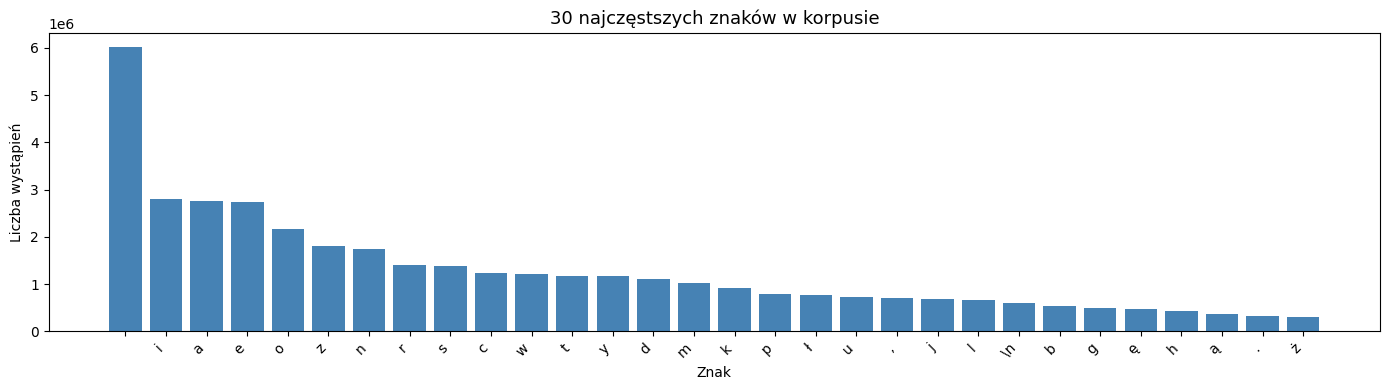

In [3]:
# ============================================================
# KOMÓRKA 3: Budowanie słownika znaków
# ============================================================

ZNAK_START = '\t'   # token początku — gwarantujemy, że nie ma go w tekstach
ZNAK_STOP  = '\n'   # token końca — naturalny koniec wiersza

# Zbieramy wszystkie unikalne znaki + token START, sortujemy dla powtarzalności
wszystkie_znaki = sorted(set(pelny_tekst) | {ZNAK_START})

# Słowniki: znak <-> indeks liczbowy
znak_na_idx = {z: i for i, z in enumerate(wszystkie_znaki)}
idx_na_znak = {i: z for z, i in znak_na_idx.items()}

ROZMIAR_SLOWNIKA = len(wszystkie_znaki)

print(f"Rozmiar słownika: {ROZMIAR_SLOWNIKA} unikalnych znaków")
print(f"  Znaki ASCII (< 128):          {sum(1 for z in wszystkie_znaki if ord(z) < 128)}")
print(f"  Polskie diakrytyki (U+0100+): {sum(1 for z in wszystkie_znaki if ord(z) >= 0x100)}")
print(f"\nIndeks ZNAK_START (TAB): {znak_na_idx[ZNAK_START]}")
print(f"Indeks ZNAK_STOP  (\\n):  {znak_na_idx[ZNAK_STOP]}")

# --- Wizualizacja częstości znaków ---
czestosci = {z: pelny_tekst.count(z) for z in wszystkie_znaki if z != ZNAK_START}
top30 = sorted(czestosci.items(), key=lambda x: -x[1])[:30]

fig, ax = plt.subplots(figsize=(14, 4))
etykiety = [repr(z)[1:-1] for z, _ in top30]   # repr usuwa cudzysłowy
wartosci = [c for _, c in top30]
ax.bar(etykiety, wartosci, color='steelblue')
ax.set_title('30 najczęstszych znaków w korpusie', fontsize=13)
ax.set_xlabel('Znak')
ax.set_ylabel('Liczba wystąpień')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rozklad_znakow.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Przygotowanie danych treningowych

### Schemat par treningowych

Przesuwamy okno długości `SEQ_LEN` po korpusie z krokiem `KROK`:

```
Korpus:  ...L i t w o !   O j c z y z n o ...
          ^<------------- SEQ_LEN = 40 ----------->^

encoder_wejscie[i]  =  tekst[i   : i+40]      np. "Litwo! Ojczyzno moja! ty jesteś jak"
decoder_wejscie[i]  =  TAB + tekst[i : i+39]  np. "► Litwo! Ojczyzno moja! ty jesteś ja"
decoder_cel[i]      =  tekst[i   : i+40]      np. "Litwo! Ojczyzno moja! ty jesteś jak"
```

### Teacher Forcing

Podczas treningu dekoder dostaje jako wejście **prawdziwy** poprzedni znak (z danych),
a nie własną predykcję. Dzięki temu:
- gradient jest stabilny (błąd nie kumuluje się),
- model uczy się szybciej.

Dlatego `decoder_wejscie` jest przesunięte o 1 w stosunku do `decoder_cel`:

```
decoder_wejscie:  [START] [L] [i] [t] [w] [o]  ...  [j] [a]
decoder_cel:      [L]     [i] [t] [w] [o] [!]  ...  [j] [a] [k]
                   ^ na każdym kroku cel jest o 1 do przodu
```

In [4]:
# ============================================================
# KOMÓRKA 4: Tworzenie par treningowych (kodowanie one-hot)
# ============================================================

# --- Hiperparametry ---
DLUGOSC_SEKWENCJI = 40    # długość okna wejściowego (liczba znaków)
KROK              = 3     # przesunięcie między kolejnymi próbkami
                          # mniejszy krok = więcej próbek, więcej pamięci
MAX_PROBEK = 10_000       # limit próbek; zmniejsz do 3000-5000 jeśli masz < 8 GB RAM

# Zbieramy ciągi wejściowe i docelowe
sekwencje_zrodlowe = []
sekwencje_celowe   = []

for i in range(0, len(pelny_tekst) - DLUGOSC_SEKWENCJI - 1, KROK):
    sekwencje_zrodlowe.append(pelny_tekst[i : i + DLUGOSC_SEKWENCJI])
    sekwencje_celowe.append(  pelny_tekst[i : i + DLUGOSC_SEKWENCJI])
    if len(sekwencje_zrodlowe) >= MAX_PROBEK:
        break

LICZBA_PROBEK = len(sekwencje_zrodlowe)
print(f"Liczba par treningowych: {LICZBA_PROBEK:,}")
print(f"\nPrzykład próbki nr 0:")
print(f"  Źródło: {repr(sekwencje_zrodlowe[0])}")
print(f"  Cel:    {repr(sekwencje_celowe[0])}")

# --- Kodowanie one-hot ---
# Tworzymy trzy tablice NumPy o kształcie (N, SEQ_LEN, VOCAB_SIZE)
# Używamy float32 dla zgodności z TensorFlow i mniejszego zużycia pamięci

print(f"\nAlokowanie tablic one-hot...")
t0 = time.time()

# Tablice inicjalizowane zerami — ustawimy jedynki tylko tam, gdzie trzeba
encoder_wejscie = np.zeros(
    (LICZBA_PROBEK, DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
decoder_wejscie = np.zeros(
    (LICZBA_PROBEK, DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
decoder_cel = np.zeros(
    (LICZBA_PROBEK, DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)

for i, (zrodlo, cel) in enumerate(zip(sekwencje_zrodlowe, sekwencje_celowe)):
    # Enkoder: sekwencja wejściowa, jeden znak na czas
    for t, znak in enumerate(zrodlo):
        encoder_wejscie[i, t, znak_na_idx[znak]] = 1.0

    # Dekoder wejście: token START + cel bez ostatniego znaku
    decoder_wejscie[i, 0, znak_na_idx[ZNAK_START]] = 1.0   # pozycja t=0: START
    for t, znak in enumerate(cel[:-1]):                     # pozycje t=1..SEQ_LEN-1
        decoder_wejscie[i, t + 1, znak_na_idx[znak]] = 1.0

    # Dekoder cel: cała sekwencja docelowa (przesunięta o 1 względem wejścia)
    for t, znak in enumerate(cel):
        decoder_cel[i, t, znak_na_idx[znak]] = 1.0

elapsed = time.time() - t0
print(f"Czas kodowania: {elapsed:.1f}s")
print(f"\nKształty tablic:")
print(f"  encoder_wejscie: {encoder_wejscie.shape}  "
      f"({encoder_wejscie.nbytes / 1e6:.0f} MB)")
print(f"  decoder_wejscie: {decoder_wejscie.shape}  "
      f"({decoder_wejscie.nbytes / 1e6:.0f} MB)")
print(f"  decoder_cel:     {decoder_cel.shape}  "
      f"({decoder_cel.nbytes / 1e6:.0f} MB)")
print(f"  Łącznie: "
      f"{(encoder_wejscie.nbytes + decoder_wejscie.nbytes + decoder_cel.nbytes) / 1e6:.0f} MB")

Liczba par treningowych: 10,000

Przykład próbki nr 0:
  Źródło: 'A jednak ja nie wątpię — bo się pora zbl'
  Cel:    'A jednak ja nie wątpię — bo się pora zbl'

Alokowanie tablic one-hot...
Czas kodowania: 0.3s

Kształty tablic:
  encoder_wejscie: (10000, 40, 270)  (432 MB)
  decoder_wejscie: (10000, 40, 270)  (432 MB)
  decoder_cel:     (10000, 40, 270)  (432 MB)
  Łącznie: 1296 MB


---
## 4. Architektura modelu Seq2Seq

### Enkoder

```
Input(None, VOCAB_SIZE) → LSTM(LATENT_DIM, return_state=True) → [h, c]
```

- `return_state=True`: zwraca oprócz wyjść LSTM także końcowe stany `h` (hidden) i `c` (cell)
- `return_sequences=False` (domyślnie): pomijamy sekwencję wyjść — potrzebujemy tylko `[h, c]`

### Dekoder

```
Input(None, VOCAB_SIZE) → LSTM(LATENT_DIM, return_sequences=True, initial_state=[h,c])
                        → Dense(VOCAB_SIZE, softmax)
```

- `initial_state=[h, c]` — **kluczowy element**: dekoder inicjalizujemy stanami enkodera
- `return_sequences=True` — potrzebujemy predykcji dla każdego kroku czasowego
- Warstwa Dense z softmax daje rozkład prawdopodobieństwa po wszystkich znakach słownika

### Parametry modelu

| Warstwa | Wzór | Przybliżona liczba parametrów |
|---------|------|-------------------------------|
| LSTM enkoder | `4 × (VOCAB + LATENT + 1) × LATENT` | ~112 K |
| LSTM dekoder | `4 × (VOCAB + LATENT + 1) × LATENT` | ~112 K |
| Dense wyjście | `LATENT × VOCAB + VOCAB` | ~12 K |
| **Razem** | | **~236 K** |

In [5]:
# ============================================================
# KOMÓRKA 5: Budowanie modelu treningowego
# ============================================================

# Wymiar wektora ukrytego LSTM
# Większy = lepsza jakość, ale wolniejszy trening i więcej pamięci
WYMIAR_UKRYTY = 128

# ── ENKODER ─────────────────────────────────────────────────

# Wejście: sekwencja znaków zakodowanych one-hot
# shape=(None, VOCAB_SIZE) — None oznacza dowolną długość sekwencji
wejscie_enkodera = Input(
    shape=(None, ROZMIAR_SLOWNIKA),
    name='wejscie_enkodera'
)

# LSTM enkodera przetwarzający całą sekwencję wejściową
# Potrzebujemy tylko końcowych stanów [h, c] — dlatego return_sequences=False
lstm_enkoder = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=False,   # nie potrzebujemy pośrednich wyjść
    return_state=True,        # ale potrzebujemy stanów końcowych
    name='lstm_enkoder'
)
# _ to wyjścia sekwencji (ignorujemy), stan_h i stan_c to wektor kontekstu
_, stan_h, stan_c = lstm_enkoder(wejscie_enkodera)
stany_enkodera = [stan_h, stan_c]   # wektor kontekstu

# ── DEKODER ─────────────────────────────────────────────────

# Wejście dekodera: sekwencja docelowa z tokenem START na początku
wejscie_dekodera = Input(
    shape=(None, ROZMIAR_SLOWNIKA),
    name='wejscie_dekodera'
)

# LSTM dekodera — inicjalizowany stanami enkodera (to serce architektury seq2seq!)
# return_sequences=True — chcemy predykcji dla KAŻDEGO kroku czasowego
lstm_dekoder = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=True,   # chcemy wyjście dla każdego kroku
    return_state=True,       # stany potrzebne w modelu inferencyjnym
    name='lstm_dekoder'
)
# Przekazujemy stany enkodera jako stan początkowy dekodera
wyjscie_dekodera, _, _ = lstm_dekoder(
    wejscie_dekodera,
    initial_state=stany_enkodera   # tu trafia wektor kontekstu
)

# Warstwa wyjściowa: dla każdego kroku czasowego daje rozkład po słowniku
# Softmax → wartości z zakresu [0, 1], sumujące się do 1 (prawdopodobieństwa)
warstwa_dense = Dense(
    ROZMIAR_SLOWNIKA,
    activation='softmax',
    name='wyjscie_dense'
)
wyjscie_dekodera = warstwa_dense(wyjscie_dekodera)

# ── MODEL TRENINGOWY ─────────────────────────────────────────

# Łączymy enkoder i dekoder w jeden model
model = Model(
    inputs=[wejscie_enkodera, wejscie_dekodera],
    outputs=wyjscie_dekodera,
    name='model_seq2seq_trening'
)

# Funkcja straty: categorical_crossentropy (bo mamy wektory one-hot)
# Optymalizator: Adam — dobry domyślny wybór dla sieci rekurencyjnych
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1777357935.851987   14137 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6750 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "model_seq2seq_trening"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wejscie_enkodera    │ (None, None, 270) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wejscie_dekodera    │ (None, None, 270) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_enkoder (LSTM) │ [(None, 128),     │    204,288 │ wejscie_enkodera… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dekoder (LSTM) │ [(None, None,     │    204,288 │ wejscie_dekodera… │
│                     │ 128), (None,      │            │ lstm_enkoder[0][… │
│                     │ 128), (None,      │            │ lstm_enkoder[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wyjscie_dense       │ (None, None, 270) │     34,830 │ lstm_dekoder[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 443,406 (1.69 MB)

 Trainable params: 443,406 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# KOMÓRKA 6: Modele inferencyjne (do generowania tekstu)
# ============================================================
#
# Podczas generowania nie możemy użyć modelu treningowego,
# bo teacher forcing wymaga podania całej sekwencji na raz.
# Musimy generować ZNAK PO ZNAKU.
#
# Kluczowa sztuczka: reużywamy tych samych warstw (lstm_enkoder,
# lstm_dekoder, warstwa_dense) — wagi są WSPÓLNE z modelem treningowym!

# --- Model enkodera (inferencja) ---
# Wejście: prompt (dowolna długość)
# Wyjście: stany ukryte [h, c] — wektor kontekstu
model_enkoder = Model(
    inputs=wejscie_enkodera,
    outputs=stany_enkodera,
    name='model_enkoder_inferency'
)

# --- Model dekodera (inferencja) ---
# Wejście: JEDEN znak + stany [h, c] z poprzedniego kroku
# Wyjście: rozkład prawdopodobieństwa po znakach + nowe stany [h', c']

# Wejścia stanów (karmione wynikami z poprzedniego kroku lub z enkodera)
wejscie_stan_h = Input(shape=(WYMIAR_UKRYTY,), name='wejscie_stan_h')
wejscie_stan_c = Input(shape=(WYMIAR_UKRYTY,), name='wejscie_stan_c')

# Reużywamy TEJ SAMEJ warstwy lstm_dekoder z modelu treningowego
wyj_inf, nowy_h, nowy_c = lstm_dekoder(
    wejscie_dekodera,
    initial_state=[wejscie_stan_h, wejscie_stan_c]
)
# Reużywamy TEJ SAMEJ warstwy dense
wyj_inf = warstwa_dense(wyj_inf)

model_dekoder = Model(
    inputs=[wejscie_dekodera, wejscie_stan_h, wejscie_stan_c],
    outputs=[wyj_inf, nowy_h, nowy_c],
    name='model_dekoder_inferency'
)

print("Model enkodera (inferencja):")
print(f"  Wejście:  sekwencja one-hot (dowolna długość)")
print(f"  Wyjście:  [h, c] — dwa wektory {WYMIAR_UKRYTY}-wymiarowe")
print()
print("Model dekodera (inferencja):")
print(f"  Wejście:  [1 znak one-hot, h, c]")
print(f"  Wyjście:  [predykcja {ROZMIAR_SLOWNIKA} znaków, nowy_h, nowy_c]")

Model enkodera (inferencja):
  Wejście:  sekwencja one-hot (dowolna długość)
  Wyjście:  [h, c] — dwa wektory 128-wymiarowe

Model dekodera (inferencja):
  Wejście:  [1 znak one-hot, h, c]
  Wyjście:  [predykcja 270 znaków, nowy_h, nowy_c]


---
## 5. Trening modelu

Używamy dwóch **callbacków** Keras:

| Callback | Działanie |
|----------|-----------|
| `EarlyStopping` | Zatrzymuje trening jeśli `val_loss` nie maleje przez `patience` epok |
| `ReduceLROnPlateau` | Zmniejsza *learning rate* o `factor` gdy postęp się zatrzymuje |

**Szacowany czas treningu na CPU:** ~4–8 minut przy 10 000 próbek.

In [7]:
# ============================================================
# KOMÓRKA 7: Trening modelu
# ============================================================

LICZBA_EPOK      = 100
WIELKOSC_BATCHA  = 128
UDZIAL_WALIDACJI = 0.1    # 10% danych jako zbiór walidacyjny

callbacki = [
    # Zatrzymaj jeśli strata walidacyjna nie maleje przez 15 epok
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,   # przywróć najlepsze wagi po zatrzymaniu
        verbose=1
    ),
    # Zmniejsz learning rate o połowę jeśli strata stoi w miejscu przez 7 epok
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=1
    )
]

print(f"Parametry treningu:")
print(f"  Próbek:  {LICZBA_PROBEK:,}  "
      f"({int(LICZBA_PROBEK*(1-UDZIAL_WALIDACJI)):,} trening / "
      f"{int(LICZBA_PROBEK*UDZIAL_WALIDACJI):,} walidacja)")
print(f"  Epoki:   max {LICZBA_EPOK} (z early stopping)")
print(f"  Batch:   {WIELKOSC_BATCHA}")
print()

t_start = time.time()

historia = model.fit(
    [encoder_wejscie, decoder_wejscie],   # dane wejściowe (lista)
    decoder_cel,                           # dane docelowe
    batch_size=WIELKOSC_BATCHA,
    epochs=LICZBA_EPOK,
    validation_split=UDZIAL_WALIDACJI,
    callbacks=callbacki,
    verbose=1
)

t_total = time.time() - t_start
epoki_wykonane = len(historia.history['loss'])
print(f"\nTrening zakończony:")
print(f"  Czas:               {t_total/60:.1f} min")
print(f"  Wykonane epoki:     {epoki_wykonane}")
print(f"  Najlepsza val_loss: {min(historia.history['val_loss']):.4f}")
print(f"  Najlepsza val_acc:  {max(historia.history['val_accuracy']):.1%}")

Parametry treningu:
  Próbek:  10,000  (9,000 trening / 1,000 walidacja)
  Epoki:   max 100 (z early stopping)
  Batch:   128

Epoch 1/100


I0000 00:00:1777357940.162441   14830 cuda_dnn.cc:461] Loaded cuDNN version 91900


71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.1411 - loss: 3.8312 - val_accuracy: 0.1419 - val_loss: 3.3243 - learning_rate: 0.0010
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1480 - loss: 3.3354 - val_accuracy: 0.1419 - val_loss: 3.2958 - learning_rate: 0.0010
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1480 - loss: 3.2816 - val_accuracy: 0.1419 - val_loss: 3.2287 - learning_rate: 0.0010
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1546 - loss: 3.1719 - val_accuracy: 0.1769 - val_loss: 3.0996 - learning_rate: 0.0010
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2286 - loss: 2.9939 - val_accuracy: 0.2297 - val_loss: 2.9322 - learning_rate: 0.0010
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2701 - loss: 2.8106 - val_accuracy: 0.2596 - val_loss: 2.7954 - learning_rate: 0.0010
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2835 - loss: 2.6792 - val_accuracy

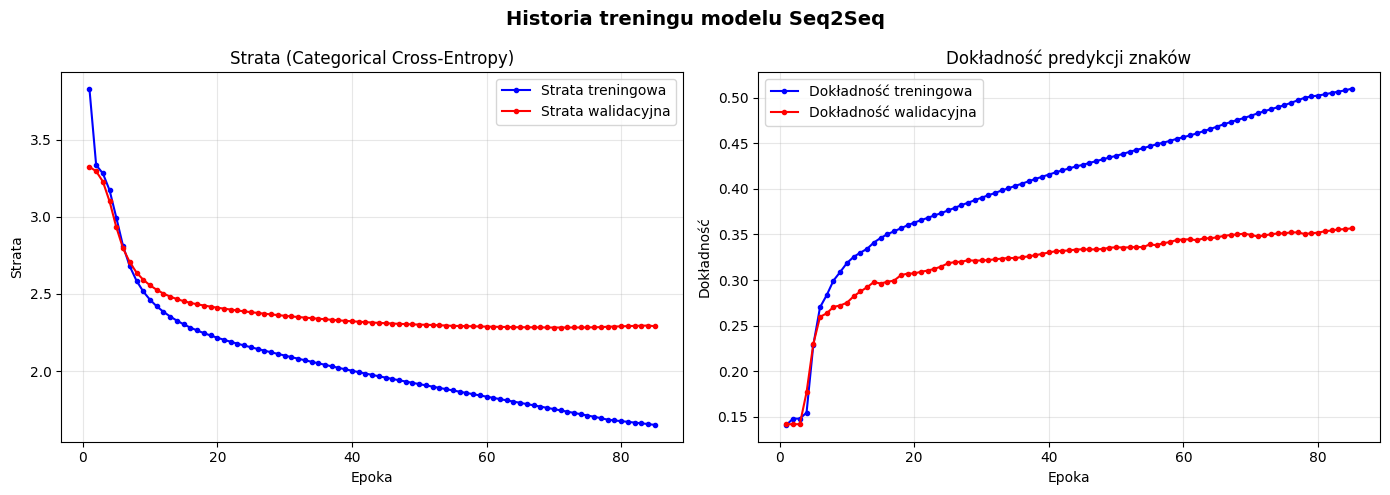

Interpretacja:
  Dok. końcowa (walidacja): 35.7%

  Uwaga: dokładność ~30-40% to DOBRY wynik dla modelu znakowego bez attention.
  Model przewiduje 1 z ~90 możliwych znaków — losowe zgadywanie to ok. 1%.


In [8]:
# ============================================================
# KOMÓRKA 8: Wizualizacja historii treningu
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epoki = range(1, len(historia.history['loss']) + 1)

# Wykres 1: strata (loss)
ax1.plot(epoki, historia.history['loss'],
         'b-o', markersize=3, label='Strata treningowa')
ax1.plot(epoki, historia.history['val_loss'],
         'r-o', markersize=3, label='Strata walidacyjna')
ax1.set_title('Strata (Categorical Cross-Entropy)', fontsize=12)
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Strata')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres 2: dokładność
ax2.plot(epoki, historia.history['accuracy'],
         'b-o', markersize=3, label='Dokładność treningowa')
ax2.plot(epoki, historia.history['val_accuracy'],
         'r-o', markersize=3, label='Dokładność walidacyjna')
ax2.set_title('Dokładność predykcji znaków', fontsize=12)
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Dokładność')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Historia treningu modelu Seq2Seq', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('historia_treningu.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacja:")
print(f"  Dok. końcowa (walidacja): {historia.history['val_accuracy'][-1]:.1%}")
print()
print("  Uwaga: dokładność ~30-40% to DOBRY wynik dla modelu znakowego bez attention.")
print("  Model przewiduje 1 z ~90 możliwych znaków — losowe zgadywanie to ok. 1%.")

---
## 6. Generowanie tekstu

### Próbkowanie z temperaturą

Zamiast zawsze wybierać znak z najwyższym prawdopodobieństwem (*greedy decoding*),
używamy **próbkowania z temperaturą $T$**:

$$P'(z_i) = \frac{\exp\!\left(\tfrac{\log P(z_i)}{T}\right)}{\displaystyle\sum_j \exp\!\left(\tfrac{\log P(z_j)}{T}\right)}$$

| Temperatura $T$ | Zachowanie modelu |
|-----------------|-------------------|
| $T \to 0$ (greedy) | Zawsze wybiera najlepszy znak — deterministyczne, może się zapętlać |
| $T = 0.5$ | Dobra równowaga jakości i różnorodności |
| $T = 1.0$ | Oryginalne prawdopodobieństwa modelu |
| $T > 1.0$ | Bardziej losowe, kreatywne, ale może generować nieistniejące słowa |

In [9]:
# ============================================================
# KOMÓRKA 9: Funkcje generowania tekstu
# ============================================================

def probkuj_z_temperatura(predykcje: np.ndarray, temperatura: float = 1.0) -> int:
    """
    Losuje indeks znaku z rozkładu zmodyfikowanego przez temperaturę.

    Argumenty:
        predykcje:   wektor prawdopodobieństw z warstwy softmax
        temperatura: parametr losowości (mały = deterministyczny, duży = losowy)

    Zwraca:
        indeks wybranego znaku w słowniku
    """
    predykcje = np.asarray(predykcje, dtype=np.float64)

    # Logarytmujemy i skalujemy przez temperaturę
    log_pred = np.log(predykcje + 1e-10) / temperatura

    # Numerycznie stabilna wersja softmax: odejmujemy maksimum przed exp()
    exp_pred = np.exp(log_pred - np.max(log_pred))
    prob = exp_pred / np.sum(exp_pred)

    # Losowanie multinomialne: 1 próba z rozkładu prob
    return np.argmax(np.random.multinomial(1, prob))


def generuj_tekst(
    prompt: str,
    max_dlugosc: int = 200,
    temperatura: float = 0.5
) -> str:
    """
    Generuje kontynuację tekstu na podstawie podanego promptu.

    Argumenty:
        prompt:       tekst wejściowy (optymalne 20-50 znaków)
        max_dlugosc:  maksymalna liczba generowanych znaków
        temperatura:  parametr losowości (0.1-2.0)

    Zwraca:
        wygenerowana kontynuacja (bez promptu)
    """
    if not prompt:
        raise ValueError("Prompt nie może być pusty")

    # Krok 1: Enkodowanie promptu
    # Tworzymy tensor one-hot dla całego promptu
    wejscie_enc = np.zeros(
        (1, len(prompt), ROZMIAR_SLOWNIKA), dtype=np.float32
    )
    for t, znak in enumerate(prompt):
        if znak in znak_na_idx:
            wejscie_enc[0, t, znak_na_idx[znak]] = 1.0
        # Znaki spoza słownika pozostają jako wektor zerowy (bezpieczne pominięcie)

    # Enkoder przetwarza cały prompt i zwraca wektor kontekstu [h, c]
    stany = model_enkoder.predict(wejscie_enc, verbose=0)
    h, c = stany[0], stany[1]

    # Krok 2: Dekodowanie znak po znaku
    # Zaczynamy od tokenu START
    aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
    aktualny_znak[0, 0, znak_na_idx[ZNAK_START]] = 1.0

    wygenerowany = ''

    for _ in range(max_dlugosc):
        # Jeden krok dekodera: znak + stany → predykcja + nowe stany
        predykcje, h, c = model_dekoder.predict(
            [aktualny_znak, h, c], verbose=0
        )

        # Wybierz kolejny znak (próbkowanie z temperaturą)
        idx = probkuj_z_temperatura(predykcje[0, 0, :], temperatura)
        nowy_znak = idx_na_znak[idx]
        wygenerowany += nowy_znak

        # Zaktualizuj wejście dekodera na następny krok
        aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
        aktualny_znak[0, 0, idx] = 1.0

    return wygenerowany


print("Funkcje generowania zdefiniowane. Uruchom kolejną komórkę, aby zobaczyć wyniki!")

Funkcje generowania zdefiniowane. Uruchom kolejną komórkę, aby zobaczyć wyniki!


In [10]:
# ============================================================
# KOMÓRKA 10: Przykłady generowania przy różnych temperaturach
# ============================================================

# Klasyczny incipit Pana Tadeusza — dobrze znany punkt odniesienia
PROMPT = "Litwo! Ojczyzno moja! ty jesteś jak zdrowi"

print("=" * 65)
print(f"PROMPT: {repr(PROMPT)}")
print("=" * 65)

for temperatura in [0.2, 0.5, 1.0, 1.5]:
    print(f"\n── Temperatura = {temperatura} " + "─" * 40)
    np.random.seed(SEED)   # resetujemy ziarno dla porównywalności wyników
    tekst = generuj_tekst(PROMPT, max_dlugosc=250, temperatura=temperatura)
    # Wyświetlamy prompt + wygenerowaną kontynuację
    print(PROMPT + tekst)

print("\n" + "=" * 65)
print("Obserwacje:")
print("  T=0.2: zdeterminowany, może się powtarzać")
print("  T=0.5: dobra równowaga jakości i różnorodności")
print("  T=1.0: zgodny z oryginalnym rozkładem modelu")
print("  T=1.5: kreatywny, ale może tworzyć nieistniejące słowa")

PROMPT: 'Litwo! Ojczyzno moja! ty jesteś jak zdrowi'

── Temperatura = 0.2 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowie się d'Artagnan, zakrząc poworzenie w to mowa za tak na poszowie, jest za stawie, panie za przeczymi na podzielinam się w to mowa za to postowie się d'Artagnan, przypowienie — odezwał się Atos — rzekł Atos — odezwał się Atos — zawałowie, tak się do 

── Temperatura = 0.5 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowina zastał odpował d'Artagnan.

— Otóż Aramis — odezwał się d'Artagnan, zawał da wszykami do wiedził Atos — odpierował się przez posznę z się był się w to miejsze na podędziem nie zobroja się nie odpowiedziej nie wraziem mi drasz konia.

— To cztery u

── Temperatura = 1.0 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowinajmyci furzenia.

— Bomówc „diego, zekłudziem wygoco, btów ma d nmnie ozborany Amouja to przydarę?


— Ho Emie;.

— Źle rwycz opr

In [13]:
# ============================================================
# KOMÓRKA 11: Interaktywna generacja — zmień i eksperymentuj!
# ============================================================

# Zmień poniższe trzy zmienne i uruchom komórkę ponownie
TWOJ_PROMPT      = "Polska jest krajem "   # wpisz własny fragment
TWOJA_TEMPERATURA = 0.1                    # wartości: 0.1 (deterministyczny) do 2.0 (losowy)
TWOJA_DLUGOSC    = 400                     # liczba generowanych znaków

print(f"Prompt:       {repr(TWOJ_PROMPT)}")
print(f"Temperatura:  {TWOJA_TEMPERATURA}")
print("-" * 65)
wynik = generuj_tekst(TWOJ_PROMPT, TWOJA_DLUGOSC, TWOJA_TEMPERATURA)
print(TWOJ_PROMPT + wynik)

Prompt:       'Polska jest krajem '
Temperatura:  0.1
-----------------------------------------------------------------
Polska jest krajem ie wierwsze wierz odpowołowie, że wystał się d'Artagnan.

— Czy powiedziem się w to miem się powarzycie się w to moje — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — odezwał się Atos — podziesz za pował się Atos — odezwał się Atos — odezwał się Atos — odez


In [12]:
# ============================================================
# KOMÓRKA 12: Zapis modelu na dysk
# ============================================================
# Keras 3 używa formatu .keras (architektura + wagi + konfiguracja kompilacji)

model.save('./model_seq2seq.keras')
model_enkoder.save('./model_enkoder.keras')
model_dekoder.save('./model_dekoder.keras')

print("Zapisano:")
print("  model_seq2seq.keras  — model treningowy (do kontynuowania treningu)")
print("  model_enkoder.keras  — enkoder (do inferencji)")
print("  model_dekoder.keras  — dekoder (do inferencji)")
print()
print("Aby wczytać w nowej sesji:")
print("  model_enkoder = keras.models.load_model('./model_enkoder.keras')")
print("  model_dekoder = keras.models.load_model('./model_dekoder.keras')")

Zapisano:
  model_seq2seq.keras  — model treningowy (do kontynuowania treningu)
  model_enkoder.keras  — enkoder (do inferencji)
  model_dekoder.keras  — dekoder (do inferencji)

Aby wczytać w nowej sesji:
  model_enkoder = keras.models.load_model('./model_enkoder.keras')
  model_dekoder = keras.models.load_model('./model_dekoder.keras')


---
## Podsumowanie

W tym notebooku zbudowaliśmy kompletny potok NLP od surowych danych do działającego modelu:

| Krok | Co zrobiliśmy |
|------|---------------|
| 1 | Wczytaliśmy i oczyściliśmy korpus z Wolnych Lektur |
| 2 | Zbudowaliśmy słownik znaków + kodowanie one-hot |
| 3 | Przygotowaliśmy pary treningowe z **teacher forcing** |
| 4 | Zdefiniowaliśmy enkoder LSTM i dekoder LSTM |
| 5 | Wytrenowaliśmy model z callbackami (EarlyStopping, ReduceLROnPlateau) |
| 6 | Zbudowaliśmy modele inferencyjne reużywające warstw treningowych |
| 7 | Generowaliśmy tekst z **próbkowaniem temperaturowym** |

---

## Ograniczenia modelu znakowego

- **Brak rozumienia semantycznego** — model uczy się statystycznych wzorców sekwencji znaków, nie znaczeń słów
- **Krótki kontekst** — okno 40 znaków ogranicza spójność dłuższych fragmentów
- **Brak mechanizmu uwagi** (*attention*) — enkoder musi kompresować cały kontekst do stałego wektora `[h, c]`

---

## Ćwiczenia

1. **Zmień epokę literacką**: zamień `'Romantyzm'` na `'Pozytywizm'` lub `'Modernizm'` i porównaj styl generacji.

2. **Eksperymentuj z `WYMIAR_UKRYTY`**: sprawdź jak `64` vs `256` wpływa na jakość tekstu i czas treningu.

3. **Zmień `DLUGOSC_SEKWENCJI`**: co się stanie z `SEQ_LEN=20` vs `SEQ_LEN=80`?

4. **Stacked LSTM**: dodaj drugą warstwę LSTM w dekoderze (`return_sequences=True` na pierwszej LSTM).

5. **Beam search**: zamiast próbkowania z temperaturą zaimplementuj przeszukiwanie wiązkowe — utrzymuj `k` najlepszych kandydatów w każdym kroku.

6. **Mechanizm uwagi (Attention)**: rozszerzenie architektury — dekoder może patrzeć wstecz na wszystkie wyjścia enkodera, nie tylko na końcowy stan ukryty.